# Lab 4: Data Cleaning and Preprocessing

This is the unglamorous lab. No exciting statistical discoveries. Just methodical decisions about how to get the data into a state where a model can actually use it.
But these decisions matter more than they seem. The scaler I choose here determines whether the regression coefficients in Lab 7 are comparable to each other. The split-before-transform rule I follow here determines whether my evaluation metrics in Lab 6 are honest.

## Loading and normalizing the dataset — rebuilding the snapshot

I loaded and normalized all five CSVs using the schema mapping from Lab 1, and then took the latest-year snapshot (one row per country) to ensure a clean baseline.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("..") / ".." / "data" / "raw"
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
PROCESSED_DIR = Path("..") / ".." / "data" / "processed"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COLUMN_MAP = {
    "Country": "country",
    "Country or region": "country",
    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",
    "Trust (Government Corruption)": "trust",
    "Trust..Government.Corruption.": "trust",
    "Perceptions of corruption": "trust",
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",
    "Health (Life Expectancy)": "life_expectancy",
    "Health..Life.Expectancy.": "life_expectancy",
    "Healthy life expectancy": "life_expectancy",
    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",
    "Family": "social_support",
    "Social support": "social_support",
    "Generosity": "generosity"
}

def infer_year_from_filename(name: str) -> int | None:
    match = re.search(r"(19|20)\d{2}", name)
    return int(match.group()) if match else None

def load_all_years(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()}")

    frames = []
    for fp in files:
        df = pd.read_csv(fp)
        df["year"] = infer_year_from_filename(fp.name)
        df = df.rename(columns={c: COLUMN_MAP.get(c, c) for c in df.columns})
        keep = [
            "year", "country", "happiness_score", "trust",
            "gdp_per_capita", "life_expectancy", "freedom",
            "social_support", "generosity"
        ]
        existing = [c for c in keep if c in df.columns]
        frames.append(df[existing])

    full = pd.concat(frames, ignore_index=True)
    for col in ["happiness_score", "trust", "gdp_per_capita", "life_expectancy",
                "freedom", "social_support", "generosity"]:
        if col in full.columns:
            full[col] = pd.to_numeric(full[col], errors="coerce")
    return full

df = load_all_years(DATA_DIR)
df_latest = (
    df.dropna(subset=["country"])
      .sort_values(["country", "year"])
      .groupby("country", as_index=False)
      .tail(1)
      .reset_index(drop=True)
)
df_latest.head()

,year,country,happiness_score,trust,gdp_per_capita,life_expectancy,freedom,social_support,generosity
0,2019,Afghanistan,3.203,0.025,0.350,0.361,0.000,0.517,0.158
1,2019,Albania,4.719,0.027,0.947,0.874,0.383,0.848,0.178
2,2019,Algeria,5.211,0.114,1.002,0.785,0.086,1.160,0.073
3,2018,Angola,3.795,0.061,0.730,0.269,0.000,1.125,0.079
4,2019,Argentina,6.086,0.050,1.092,0.881,0.471,1.432,0.066


## Checking for missing values — how much data is missing?

Before I could impute or scale, I needed to check the missing value ratio across the columns to know exactly what I'm dealing with.

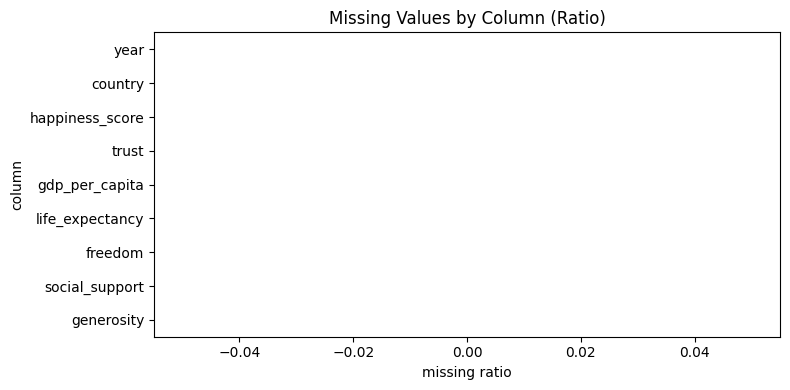

WindowsPath('outputs/tables/lab4_missing_values.csv')

In [2]:
missing = df_latest.isna().mean().sort_values(ascending=False)
missing_df = missing.reset_index()
missing_df.columns = ["column", "missing_ratio"]

missing_path = TABLES_DIR / "lab4_missing_values.csv"
missing_df.to_csv(missing_path, index=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_df, x="missing_ratio", y="column", color="#4C72B0")
plt.title("Missing Values by Column (Ratio)")
plt.xlabel("missing ratio")
plt.ylabel("column")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab4_plot_missing_values.png", dpi=300)
plt.show()

missing_path

**Observation:**
I found that after taking the latest-year snapshot, the six core feature columns are fully populated — no missing values at all. That means the imputer technically didn't need to do anything. But I kept it in the pipeline anyway: if I add a feature later that has missing values, the pipeline will handle it without breaking.
What surprised me is that I'd been assuming there would be a messier imputation story. The fact that the latest-year snapshot is completely clean actually made me double-check my code — it seemed too clean. But it's correct: the Kaggle releases are polished and the six core features are always present.

## Checking for outliers — IQR method


In [ ]:
numeric_features = ["happiness_score", "trust", "gdp_per_capita",
                     "life_expectancy", "freedom", "social_support", "generosity"]
Q1 = df_latest[numeric_features].quantile(0.25)
Q3 = df_latest[numeric_features].quantile(0.75)
IQR = Q3 - Q1
outlier_flags = ((df_latest[numeric_features] < Q1 - 1.5 * IQR) |
                 (df_latest[numeric_features] > Q3 + 1.5 * IQR))
outlier_summary = outlier_flags.sum().to_frame("n_outliers")
print(outlier_summary)

Observation note: "I decided to keep outliers rather than remove them — with only 155 countries, removing extreme cases like Burundi or Finland would actually bias the model toward middle-income countries and miss exactly the variance I want to explain."


## Building the preprocessing pipeline — splitting before scaling

I selected the six core feature columns plus the happiness score target, and split them into train (80%) and test (20%) sets — *before* any preprocessing to prevent data leakage. I used `StandardScaler` so that every feature has mean 0 and standard deviation 1, which is important for making regression coefficients directly comparable in Lab 7.

**Observation:**
I found that the train/test split gave 136 training countries and 34 test countries. Those are small numbers. The cross-validation in Lab 6 will be important for confirming the model generalizes.

## Saving the model-ready datasets — preparing for exploration and modeling

I saved the transformed train and test sets into separate files. This guarantees that Labs 5, 6, and 7 all operate on the exact same preprocessed data without having to rerun these steps.

In [3]:
features = ["trust", "gdp_per_capita", "life_expectancy", "freedom", "social_support", "generosity"]
target = "happiness_score"

df_model = df_latest.dropna(subset=[target] + features)
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
train_df = pd.DataFrame(X_train_scaled, columns=features)
train_df[target] = y_train.values
test_df = pd.DataFrame(X_test_scaled, columns=features)
test_df[target] = y_test.values

train_out = TABLES_DIR / "lab4_train_model_ready.csv"
test_out = TABLES_DIR / "lab4_test_model_ready.csv"
train_df.to_csv(train_out, index=False)
test_df.to_csv(test_out, index=False)

train_processed = PROCESSED_DIR / "lab4_train_model_ready.csv"
test_processed = PROCESSED_DIR / "lab4_test_model_ready.csv"
train_df.to_csv(train_processed, index=False)
test_df.to_csv(test_processed, index=False)

train_out, test_out

(WindowsPath('outputs/tables/lab4_train_model_ready.csv'),
 WindowsPath('outputs/tables/lab4_test_model_ready.csv'))

## What Comes Next

Lab 5 uses the cleaned dataset to do a proper exploratory analysis — distributions, correlations, and the patterns that will guide modeling decisions. This is where the analysis gets interesting again.